In [146]:
'''
This script compares and plots EOF and MCA principal components for SSH, WSC and SIC
'''

'\nThis script compares and plots EOF and MCA principal components for SSH, WSC and SIC\n'

In [147]:
#import modules

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [148]:
#load EOF pcs for SSH, WSC, SIC and PCAs for their pairs
nc_file_path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
pc1_sic_sm = xr.open_dataset(nc_file_path + 'pc1_sic_sm.nc')
pc2_sic_sm = xr.open_dataset(nc_file_path + 'pc2_sic_sm.nc')

pc1_ssh_sm = xr.open_dataset(nc_file_path + 'pc1_ssh_sm.nc')
pc2_ssh_sm = xr.open_dataset(nc_file_path + 'pc2_ssh_sm.nc')

pc1_wsc_sm = xr.open_dataset(nc_file_path + 'pc1_wsc_sm.nc')
pc2_wsc_sm = xr.open_dataset(nc_file_path + 'pc2_wsc_sm.nc')

In [149]:
print(pc2_wsc_sm)

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 196)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
    mode     int64 8B ...
Data variables:
    pcs      (time) float64 2kB ...


In [150]:
#load MCA pcas for SSH, WSC, SIC
text_file_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/'
mca_pca_wsc_sic_WSC = np.genfromtxt(text_file_path + 'PCs_wsc_sic_WSC_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')
mca_pca_wsc_sic_SIC = np.genfromtxt(text_file_path + 'PCs_wsc_sic_SIC_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')

mca_pca_dot_sic_SSH = np.genfromtxt(text_file_path + 'PCs_dot_sic_SSH_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')
mca_pca_dot_sic_SIC = np.genfromtxt(text_file_path + 'PCs_dot_sic_SIC_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')

mca_pca_wsc_ssh_WSC = np.genfromtxt(text_file_path + 'PCs_wsc_ssh_WSC_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')
mca_pca_wsc_ssh_SSH = np.genfromtxt(text_file_path + 'PCs_wsc_ssh_SSH_remapcon_seas.txt', delimiter='\t', names=True, dtype=None, encoding='utf-8')

In [151]:
#convert to dataset (MCA PCAS)

mca_pca_wsc_sic_WSC_df = pd.DataFrame(mca_pca_wsc_sic_WSC)               # Make time the index
mca_pca_wsc_sic_SIC_df = pd.DataFrame(mca_pca_wsc_sic_SIC)

mca_pca_dot_sic_SSH_df = pd.DataFrame(mca_pca_dot_sic_SSH)
mca_pca_dot_sic_SIC_df = pd.DataFrame(mca_pca_dot_sic_SIC)

mca_pca_wsc_ssh_WSC_df = pd.DataFrame(mca_pca_wsc_ssh_WSC)
mca_pca_wsc_ssh_SSH_df = pd.DataFrame(mca_pca_wsc_ssh_SSH)

######

mca_pca_wsc_sic_WSC_df['time'] = pd.to_datetime(mca_pca_wsc_sic_WSC_df['time'])
mca_pca_wsc_sic_WSC_df = mca_pca_wsc_sic_WSC_df.set_index('time')
mca_pca_wsc_sic_SIC_df['time'] = pd.to_datetime(mca_pca_wsc_sic_SIC_df['time'])
mca_pca_wsc_sic_SIC_df = mca_pca_wsc_sic_SIC_df.set_index('time')

mca_pca_dot_sic_SSH_df['time'] = pd.to_datetime(mca_pca_dot_sic_SSH_df['time'])
mca_pca_dot_sic_SSH_df = mca_pca_dot_sic_SSH_df.set_index('time')
mca_pca_dot_sic_SIC_df['time'] = pd.to_datetime(mca_pca_dot_sic_SIC_df['time'])
mca_pca_dot_sic_SIC_df = mca_pca_dot_sic_SIC_df.set_index('time')

mca_pca_wsc_ssh_WSC_df['time'] = pd.to_datetime(mca_pca_wsc_ssh_WSC_df['time'])
mca_pca_wsc_ssh_WSC_df = mca_pca_wsc_ssh_WSC_df.set_index('time')
mca_pca_wsc_ssh_SSH_df['time'] = pd.to_datetime(mca_pca_wsc_ssh_SSH_df['time'])
mca_pca_wsc_ssh_SSH_df = mca_pca_wsc_ssh_SSH_df.set_index('time')
#####

mca_pca_wsc_sic_WSC_ds = mca_pca_wsc_sic_WSC_df.to_xarray()
mca_pca_wsc_sic_SIC_ds = mca_pca_wsc_sic_SIC_df.to_xarray()

mca_pca_dot_sic_SSH_ds = mca_pca_dot_sic_SSH_df.to_xarray()
mca_pca_dot_sic_SIC_ds = mca_pca_dot_sic_SIC_df.to_xarray()

mca_pca_wsc_ssh_WSC_ds = mca_pca_wsc_ssh_WSC_df.to_xarray()
mca_pca_wsc_ssh_SSH_ds = mca_pca_wsc_ssh_SSH_df.to_xarray()




In [152]:
#apply rolling 6 month average to all MCA ds (need this to match the PCs from EOF)
mca_pca_wsc_sic_WSC_sm = (mca_pca_wsc_sic_WSC_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')
mca_pca_wsc_sic_SIC_sm = (mca_pca_wsc_sic_SIC_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')

mca_pca_dot_sic_SSH_sm = (mca_pca_dot_sic_SSH_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')
mca_pca_dot_sic_SIC_sm = (mca_pca_dot_sic_SIC_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')

mca_pca_wsc_ssh_WSC_sm = (mca_pca_wsc_ssh_WSC_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')
mca_pca_wsc_ssh_SSH_sm = (mca_pca_wsc_ssh_SSH_ds.rolling(time = 6, center = True).mean()).ffill('time').bfill('time')





In [153]:
#trying to do linear regression between NPP and ZW3 and SOI
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

ds_zw3 = xr.open_dataset(path + 'zw3_ds.nc')

ds_monthly_SOI = xr.open_dataset(path + 'monthly_SOI.nc')
ds_monthly_SOI_masked = xr.open_dataset(path + 'soi_sam_masked.nc')

ds_monthly_sam = xr.open_dataset('monthly_sam.nc')

formatted_time_zw3 = pd.to_datetime(ds_zw3['valid_time'].values).strftime('%Y-%m-%dT%H:%M:%S.000000000')
ds_zw3 = ds_zw3.assign_coords(valid_time=("valid_time", formatted_time_zw3))
ds_zw3 = ds_zw3.assign_coords(valid_time=pd.to_datetime(ds_zw3['valid_time'].values))

formatted_time_soi = pd.to_datetime(ds_monthly_SOI['time'].values).strftime('%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=("time", formatted_time_soi))
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=pd.to_datetime(ds_monthly_SOI['time'].values))

formatted_time_soi_masked = pd.to_datetime(ds_monthly_SOI_masked['time'].values).strftime(
    '%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=("time", formatted_time_soi_masked))
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=pd.to_datetime(ds_monthly_SOI_masked['time'].values))
smoothed_soi = ds_monthly_SOI_masked['SOI'].rolling(time=6, center=True).mean()
smoothed_zw3_idx = ds_zw3['zw3index_magnitude'].rolling(valid_time=6, center=True).mean()
smoothed_sam = ds_monthly_sam['SAM'].rolling(time=6, center=True).mean()

[Text(11869.0, 0, '2002-07'),
 Text(12234.0, 0, '2003-07'),
 Text(12600.0, 0, '2004-07'),
 Text(12965.0, 0, '2005-07'),
 Text(13330.0, 0, '2006-07'),
 Text(13695.0, 0, '2007-07'),
 Text(14061.0, 0, '2008-07'),
 Text(14426.0, 0, '2009-07'),
 Text(14791.0, 0, '2010-07'),
 Text(15156.0, 0, '2011-07'),
 Text(15522.0, 0, '2012-07'),
 Text(15887.0, 0, '2013-07'),
 Text(16252.0, 0, '2014-07'),
 Text(16617.0, 0, '2015-07'),
 Text(16983.0, 0, '2016-07'),
 Text(17348.0, 0, '2017-07'),
 Text(17713.0, 0, '2018-07')]

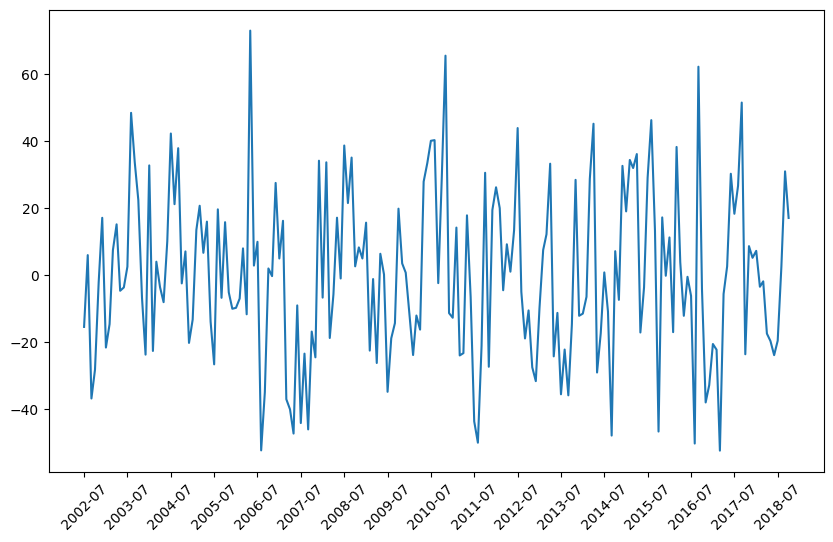

In [154]:
time = pd.to_datetime(mca_pca_wsc_sic_WSC['time'])
time_labels = pd.Series(time).dt.strftime('%Y-%m')
tick_spacing = time[::12]
fig, ax = plt.subplots(1, 1, figsize = (10, 6))
ax.plot(time,mca_pca_wsc_sic_WSC['PC1'])
ax.set_xticks(tick_spacing)
ax.set_xticklabels(time_labels[::12], rotation=45)

In [164]:
print(ds_monthly_sam['time'][546])
print(ds_monthly_sam['time'][742])
sam_idx_s = 546
sam_idx_e = 742

<xarray.DataArray 'time' ()> Size: 8B
array('2002-07-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2002-07-01T12:00:00
<xarray.DataArray 'time' ()> Size: 8B
array('2018-11-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2018-11-01T12:00:00


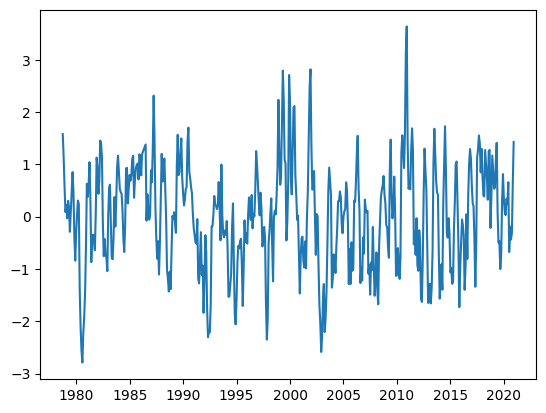

In [165]:
plt.plot(pc1_sic_sm['time'], pc1_sic_sm['pcs'])

In [166]:
start_idx_sic = 281
end_idx_sic = -26


In [171]:
#calculate correlation matrix between first 2 pcs for EOF and first 2 pcs for MCA pairs for SSH, WSC, SIC
# # Extract 1D numpy arrays

'''

this is a key for the variable names for the pcs for EOF and MCA

All variables have a 6 month rolling average applied - smoothed (some are smoothed without the _sm on the end ... use 'rolling = time( ' search to check )

SOI = Southern Oscillation Index
ZW3 = Zonal Wave 3

e = EOF
m = MCA

number shows which principal component (eg m1 = 1st principal component of MCA)

1st lower case name = forcing variable
2nd lower case name = 'reactive' variable
1st upper case name = which variables spatial principal component it is


e.g.
m1wsc_sic_WSC = 1st MCA derived PC for WSC effect on SIC. The variability that is being analysed is that of WSC.

m2wsc_ssh_SSH = 2nd MCA derived PC for WSC effect on SSH. The variability that is being analysed is that of SSH.

e1_sic = 1st PC of SIC using EOF

'''



soi_vals = smoothed_soi[1626:1822].values
zw3_vals = smoothed_zw3_idx[30:226].values
sam_vals = smoothed_sam[sam_idx_s:sam_idx_e].values

m1wsc_sic_WSC = mca_pca_wsc_sic_WSC_sm['PC1'].values
m2wsc_sic_WSC = mca_pca_wsc_sic_WSC_sm['PC2'].values
m1wsc_sic_SIC = mca_pca_wsc_sic_SIC_sm['PC1'].values
m2wsc_sic_SIC = mca_pca_wsc_sic_SIC_sm['PC2'].values

m1ssh_sic_SSH = mca_pca_dot_sic_SSH_sm['PC1'].values
m2ssh_sic_SSH = mca_pca_dot_sic_SSH_sm['PC2'].values
m1ssh_sic_SIC = mca_pca_dot_sic_SIC_sm['PC1'].values
m2ssh_sic_SIC = mca_pca_dot_sic_SIC_sm['PC2'].values

m1wsc_ssh_WSC = mca_pca_wsc_ssh_WSC_sm['PC1'].values
m2wsc_ssh_WSC = mca_pca_wsc_ssh_WSC_sm['PC2'].values
m1wsc_ssh_SSH = mca_pca_wsc_ssh_SSH_sm['PC1'].values
m2wsc_ssh_SSH = mca_pca_wsc_ssh_SSH_sm['PC2'].values


e1_sic = pc1_sic_sm['pcs'][281:-26].values
e2_sic = pc2_sic_sm['pcs'][281:-26].values
e1_wsc = pc1_wsc_sm['pcs'].values
e2_wsc = pc2_wsc_sm['pcs'].values
e1_ssh = pc1_ssh_sm['pcs'].values
e2_ssh = pc2_ssh_sm['pcs'].values



In [173]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1. Define EOF and MCA variable arrays
data_matrix = np.vstack([
    #Large scale atmos
    soi_vals, zw3_vals, sam_vals,

    # EOF PCs
    e1_sic, e2_sic,
    e1_wsc, e2_wsc,
    e1_ssh, e2_ssh,

    # MCA PCs
    m1wsc_sic_WSC, m2wsc_sic_WSC,
    m1wsc_sic_SIC, m2wsc_sic_SIC,

    m1ssh_sic_SSH, m2ssh_sic_SSH,
    m1ssh_sic_SIC, m2ssh_sic_SIC,

    m1wsc_ssh_WSC, m2wsc_ssh_WSC,
    m1wsc_ssh_SSH, m2wsc_ssh_SSH
])

# 2. Labels
labels = [
    'SOI', 'ZW3', 'SAM',
    'e1_sic', 'e2_sic',
    'e1_wsc', 'e2_wsc',
    'e1_ssh', 'e2_ssh',

    'm1wsc_sic_WSC', 'm2wsc_sic_WSC',
    'm1wsc_sic_SIC', 'm2wsc_sic_SIC',

    'm1ssh_sic_SSH', 'm2ssh_sic_SSH',
    'm1ssh_sic_SIC', 'm2ssh_sic_SIC',

    'm1wsc_ssh_WSC', 'm2wsc_ssh_WSC',
    'm1wsc_ssh_SSH', 'm2wsc_ssh_SSH'
]

# 3. Compute correlation matrices
corr_matrix_pearson = np.round(np.corrcoef(data_matrix), 3)
corr_matrix_spear, _ = np.round(spearmanr(data_matrix, axis=1), 3)

# 4. Store in DataFrames
corr_df_pearson = pd.DataFrame(corr_matrix_pearson, index=labels, columns=labels)
corr_df_spear = pd.DataFrame(corr_matrix_spear, index=labels, columns=labels)

# 5. Print
print("Pearson correlation matrix:")
print(corr_df_pearson)

print("\nSpearman correlation matrix:")
print(corr_df_spear)


Pearson correlation matrix:
                 SOI    ZW3    SAM  e1_sic  e2_sic  e1_wsc  e2_wsc  e1_ssh  \
SOI            1.000 -0.028 -0.121   0.273   0.094  -0.078   0.658   0.506   
ZW3           -0.028  1.000 -0.040   0.228  -0.305  -0.124  -0.036  -0.210   
SAM           -0.121 -0.040  1.000   0.120   0.175   0.788  -0.066   0.158   
e1_sic         0.273  0.228  0.120   1.000  -0.277   0.141   0.361   0.217   
e2_sic         0.094 -0.305  0.175  -0.277   1.000   0.171   0.128   0.308   
e1_wsc        -0.078 -0.124  0.788   0.141   0.171   1.000   0.000   0.156   
e2_wsc         0.658 -0.036 -0.066   0.361   0.128   0.000   1.000   0.671   
e1_ssh         0.506 -0.210  0.158   0.217   0.308   0.156   0.671   1.000   
e2_ssh         0.065  0.122 -0.351  -0.218   0.181  -0.598  -0.014   0.000   
m1wsc_sic_WSC -0.048 -0.131  0.739   0.161   0.164   0.982   0.029   0.127   
m2wsc_sic_WSC -0.701 -0.009  0.032  -0.359  -0.142   0.002  -0.890  -0.536   
m1wsc_sic_SIC -0.014 -0.271  0.553  

In [174]:
diff_corr = corr_df_spear - corr_df_pearson


In [176]:
# # # Save Pearson correlation matrix to text file
# corr_df_pearson.to_csv('pearson_correlation_matrix_mca_eof_pcs.txt', sep='\t', float_format='%.3f')
#
# # Save Spearman correlation matrix to text file
# corr_df_spear.to_csv('spearman_correlation_matrix_mca_eof_pcs.txt', sep='\t', float_format='%.3f')
#
# diff_corr.to_csv('diff_corr_mca_eof_pcs.txt', sep='\t', float_format='%.3f')

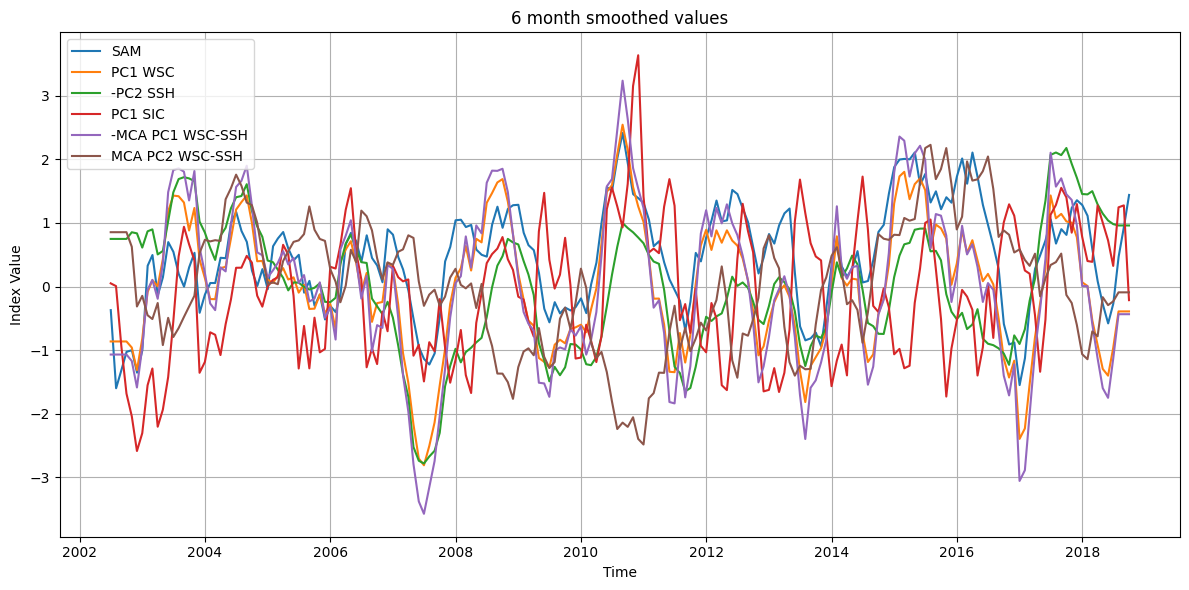

In [170]:
# Plotting
plt.figure(figsize=(12, 6))

#plt.plot(smoothed_soi['time'], smoothed_soi, label='SOI')
#plt.plot(smoothed_zw3['valid_time'], smoothed_zw3, label='ZW3')
plt.plot(smoothed_sam['time'][sam_idx_s:sam_idx_e], smoothed_sam[sam_idx_s:sam_idx_e], label='SAM')
#plt.plot(smoothed_pc1_sic['time'], smoothed_pc1_sic, label='PC1 SIC')
plt.plot(pc1_wsc_sm['time'], pc1_wsc_sm['pcs'], label='PC1 WSC')
plt.plot(pc2_ssh_sm['time'], -pc2_ssh_sm['pcs'], label='-PC2 SSH')
#plt.plot(pc2_sic_sm['time'], pc2_sic_sm, label='PC2 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], pc1_sic_sm['pcs'][281:-26], label='PC1 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], -(mca_pca_wsc_ssh_WSC_sm['PC1']/10), label='-MCA PC1 WSC-SSH')
plt.plot(pc2_sic_sm['time'][281:-26], (mca_pca_wsc_ssh_WSC_sm['PC2']/10), label='MCA PC2 WSC-SSH')


plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6 month smoothed values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





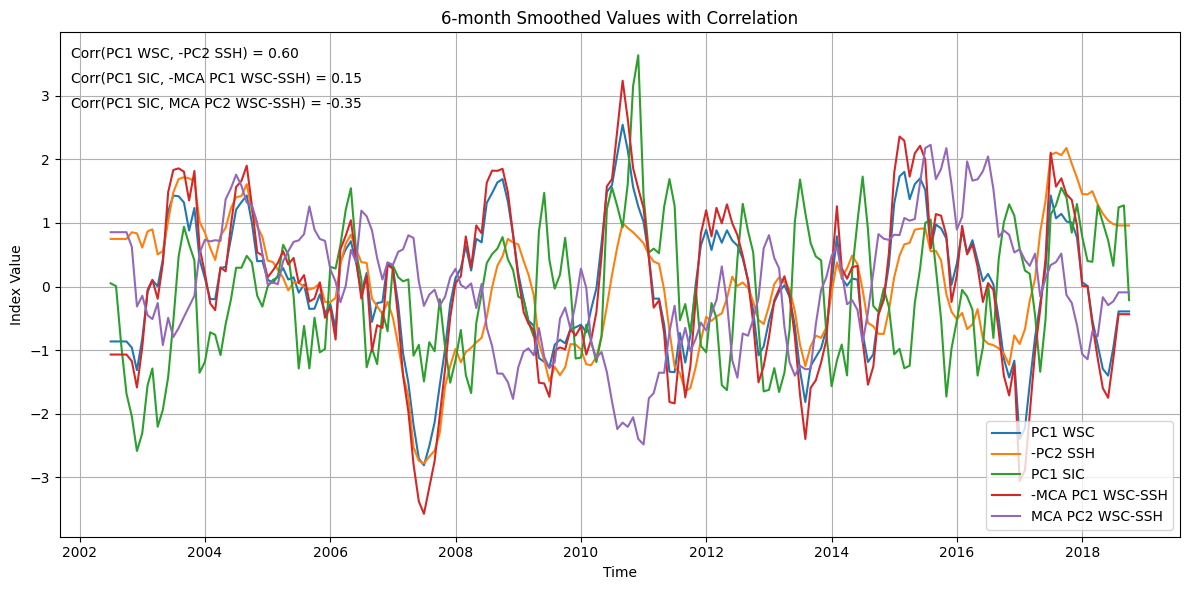

In [143]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Compute correlations (adjust slicing/indexing as needed to match time alignment)
corr1, _ = pearsonr(pc1_wsc_sm['pcs'], -pc2_ssh_sm['pcs'])
corr2, _ = pearsonr(pc1_sic_sm['pcs'][281:-26], -mca_pca_wsc_ssh_WSC_sm['PC1']/10)
corr3, _ = pearsonr(pc1_sic_sm['pcs'][281:-26], mca_pca_wsc_ssh_WSC_sm['PC2']/10)

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(pc1_wsc_sm['time'], pc1_wsc_sm['pcs'], label='PC1 WSC')
plt.plot(pc2_ssh_sm['time'], -pc2_ssh_sm['pcs'], label='-PC2 SSH')
plt.plot(pc2_sic_sm['time'][281:-26], pc1_sic_sm['pcs'][281:-26], label='PC1 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], -(mca_pca_wsc_ssh_WSC_sm['PC1']/10), label='-MCA PC1 WSC-SSH')
plt.plot(pc2_sic_sm['time'][281:-26], (mca_pca_wsc_ssh_WSC_sm['PC2']/10), label='MCA PC2 WSC-SSH')

plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6-month Smoothed Values with Correlation')
plt.legend(loc = 'lower right')
plt.grid(True)

# Add correlation text
plt.text(0.01, 0.95, f"Corr(PC1 WSC, -PC2 SSH) = {corr1:.2f}", transform=plt.gca().transAxes)
plt.text(0.01, 0.90, f"Corr(PC1 SIC, -MCA PC1 WSC-SSH) = {corr2:.2f}", transform=plt.gca().transAxes)
plt.text(0.01, 0.85, f"Corr(PC1 SIC, MCA PC2 WSC-SSH) = {corr3:.2f}", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()


In [ ]:
# Plotting
plt.figure(figsize=(12, 6))

#plt.plot(smoothed_soi['time'], smoothed_soi, label='SOI')
#plt.plot(smoothed_zw3['valid_time'], smoothed_zw3, label='ZW3')
plt.plot(smoothed_sam['time'][sam_idx_s:sam_idx_e], smoothed_sam[sam_idx_s:sam_idx_e], label='SAM')
#plt.plot(smoothed_pc1_sic['time'], smoothed_pc1_sic, label='PC1 SIC')
plt.plot(pc1_wsc_sm['time'], pc1_wsc_sm['pcs'], label='PC1 WSC')
plt.plot(pc2_ssh_sm['time'], -pc2_ssh_sm['pcs'], label='-PC2 SSH')
#plt.plot(pc2_sic_sm['time'], pc2_sic_sm, label='PC2 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], pc1_sic_sm['pcs'][281:-26], label='PC1 SIC')
plt.plot(pc2_sic_sm['time'][281:-26], -(mca_pca_wsc_ssh_WSC_sm['PC1']/10), label='-MCA PC1 WSC-SSH')
plt.plot(pc2_sic_sm['time'][281:-26], (mca_pca_wsc_ssh_WSC_sm['PC2']/10), label='MCA PC2 WSC-SSH')


plt.xlabel('Time')
plt.ylabel('Index Value')
plt.title('6 month smoothed values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





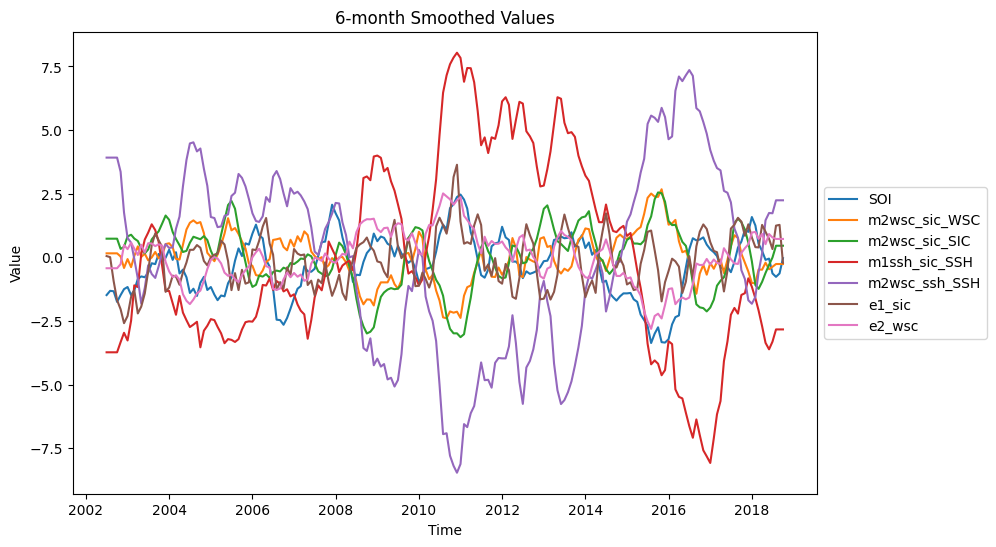

In [203]:
soi_times = smoothed_soi['time'][1626:1822]
zw3_times = smoothed_zw3_idx['valid_time'][30:226]

sam_times = smoothed_sam['time'][sam_idx_s:sam_idx_e]
sic_time = pc1_sic_sm['time'][281:-26]

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1)

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

plt.plot(soi_times, soi_vals, label='SOI')
# plt.plot(zw3_times, zw3_vals, label='ZW3')
# plt.plot(sam_times, sam_vals, label='SAM')

# plt.plot(sic_time, m1wsc_sic_WSC/10, label='m1wsc_sic_WSC')
plt.plot(sic_time, m2wsc_sic_WSC/10, label='m2wsc_sic_WSC')
# plt.plot(sic_time, m1wsc_sic_SIC/10, label='m1wsc_sic_SIC')
plt.plot(sic_time, m2wsc_sic_SIC/10, label='m2wsc_sic_SIC')

plt.plot(sic_time, m1ssh_sic_SSH/10, label='m1ssh_sic_SSH')
#plt.plot(sic_time, m2ssh_sic_SSH/10, label='m2ssh_sic_SSH')
# plt.plot(sic_time, m1ssh_sic_SIC/10, label='m1ssh_sic_SIC')
# plt.plot(sic_time, m2ssh_sic_SIC/10, label='m2ssh_sic_SIC')

# plt.plot(sic_time, m1wsc_ssh_WSC/10, label='m1wsc_ssh_WSC')
# plt.plot(sic_time, m2wsc_ssh_WSC/10, label='m2wsc_ssh_WSC')
# plt.plot(sic_time, m1wsc_ssh_SSH/10, label='m1wsc_ssh_SSH')
plt.plot(sic_time, m2wsc_ssh_SSH/10, label='m2wsc_ssh_SSH')

plt.plot(sic_time, e1_sic, label='e1_sic')
# plt.plot(sic_time, e2_sic, label='e2_sic')
# plt.plot(sic_time, e1_wsc, label='e1_wsc')
plt.plot(sic_time, e2_wsc, label='e2_wsc')
# plt.plot(sic_time, e1_ssh, label='e1_ssh')
# plt.plot(sic_time, e2_ssh, label='e2_ssh')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('6-month Smoothed Values')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

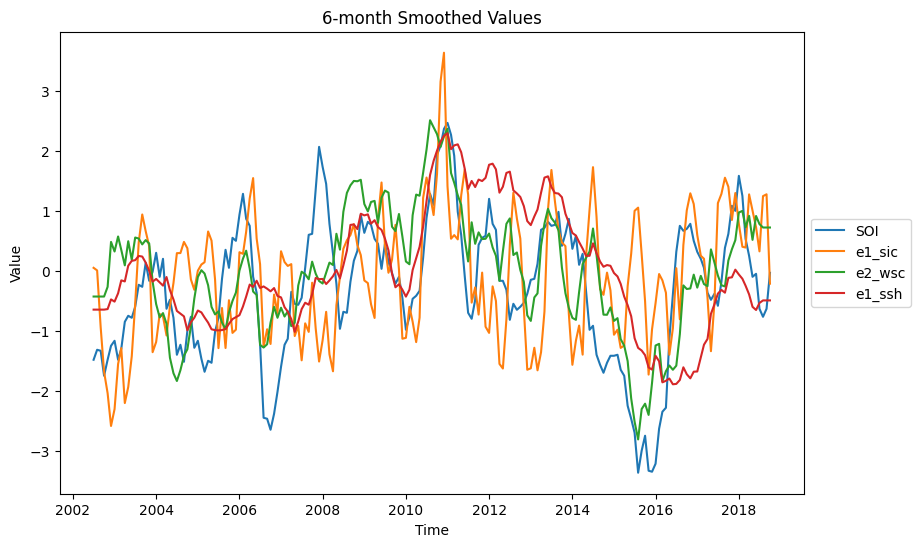

In [204]:
soi_times = smoothed_soi['time'][1626:1822]
zw3_times = smoothed_zw3_idx['valid_time'][30:226]

sam_times = smoothed_sam['time'][sam_idx_s:sam_idx_e]
sic_time = pc1_sic_sm['time'][281:-26]

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1)

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

plt.plot(soi_times, soi_vals, label='SOI')
# plt.plot(zw3_times, zw3_vals, label='ZW3')
# plt.plot(sam_times, sam_vals, label='SAM')

# plt.plot(sic_time, m1wsc_sic_WSC/10, label='m1wsc_sic_WSC')
# plt.plot(sic_time, m2wsc_sic_WSC/10, label='m2wsc_sic_WSC')
# plt.plot(sic_time, m1wsc_sic_SIC/10, label='m1wsc_sic_SIC')
# plt.plot(sic_time, m2wsc_sic_SIC/10, label='m2wsc_sic_SIC')

# plt.plot(sic_time, m1ssh_sic_SSH/10, label='m1ssh_sic_SSH')
#plt.plot(sic_time, m2ssh_sic_SSH/10, label='m2ssh_sic_SSH')
# plt.plot(sic_time, m1ssh_sic_SIC/10, label='m1ssh_sic_SIC')
# plt.plot(sic_time, m2ssh_sic_SIC/10, label='m2ssh_sic_SIC')

# plt.plot(sic_time, m1wsc_ssh_WSC/10, label='m1wsc_ssh_WSC')
# plt.plot(sic_time, m2wsc_ssh_WSC/10, label='m2wsc_ssh_WSC')
# plt.plot(sic_time, m1wsc_ssh_SSH/10, label='m1wsc_ssh_SSH')
# plt.plot(sic_time, m2wsc_ssh_SSH/10, label='m2wsc_ssh_SSH')

plt.plot(sic_time, e1_sic, label='e1_sic')
# plt.plot(sic_time, e2_sic, label='e2_sic')
# plt.plot(sic_time, e1_wsc, label='e1_wsc')
plt.plot(sic_time, e2_wsc, label='e2_wsc')
plt.plot(sic_time, e1_ssh, label='e1_ssh')
# plt.plot(sic_time, e2_ssh, label='e2_ssh')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('6-month Smoothed Values')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

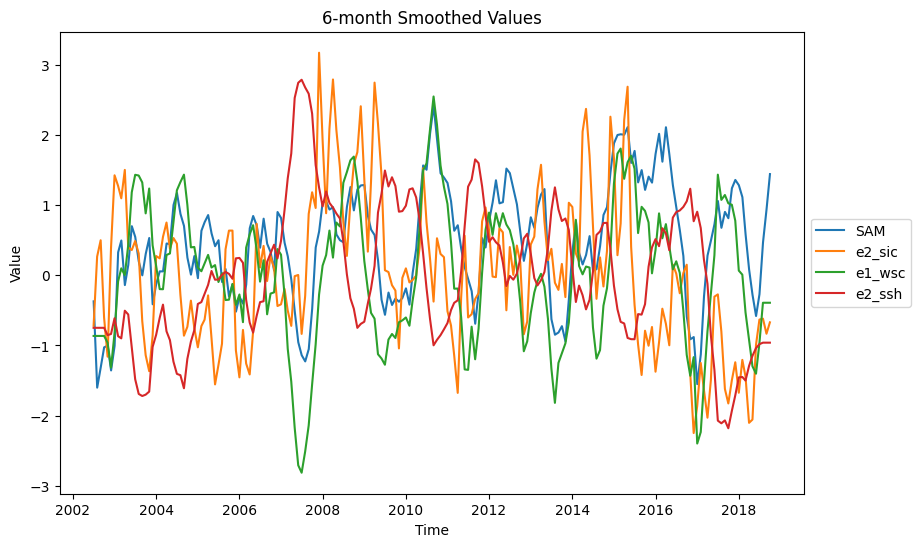

In [205]:
soi_times = smoothed_soi['time'][1626:1822]
zw3_times = smoothed_zw3_idx['valid_time'][30:226]

sam_times = smoothed_sam['time'][sam_idx_s:sam_idx_e]
sic_time = pc1_sic_sm['time'][281:-26]

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1)

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

#plt.plot(soi_times, soi_vals, label='SOI')
# plt.plot(zw3_times, zw3_vals, label='ZW3')
plt.plot(sam_times, sam_vals, label='SAM')

# plt.plot(sic_time, m1wsc_sic_WSC/10, label='m1wsc_sic_WSC')
# plt.plot(sic_time, m2wsc_sic_WSC/10, label='m2wsc_sic_WSC')
# plt.plot(sic_time, m1wsc_sic_SIC/10, label='m1wsc_sic_SIC')
# plt.plot(sic_time, m2wsc_sic_SIC/10, label='m2wsc_sic_SIC')

# plt.plot(sic_time, m1ssh_sic_SSH/10, label='m1ssh_sic_SSH')
#plt.plot(sic_time, m2ssh_sic_SSH/10, label='m2ssh_sic_SSH')
# plt.plot(sic_time, m1ssh_sic_SIC/10, label='m1ssh_sic_SIC')
# plt.plot(sic_time, m2ssh_sic_SIC/10, label='m2ssh_sic_SIC')

# plt.plot(sic_time, m1wsc_ssh_WSC/10, label='m1wsc_ssh_WSC')
# plt.plot(sic_time, m2wsc_ssh_WSC/10, label='m2wsc_ssh_WSC')
# plt.plot(sic_time, m1wsc_ssh_SSH/10, label='m1wsc_ssh_SSH')
# plt.plot(sic_time, m2wsc_ssh_SSH/10, label='m2wsc_ssh_SSH')

# plt.plot(sic_time, e1_sic, label='e1_sic')
plt.plot(sic_time, e2_sic, label='e2_sic')
plt.plot(sic_time, e1_wsc, label='e1_wsc')
# plt.plot(sic_time, e2_wsc, label='e2_wsc')
# plt.plot(sic_time, e1_ssh, label='e1_ssh')
plt.plot(sic_time, e2_ssh, label='e2_ssh')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('6-month Smoothed Values')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()